### importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib           
import quantstats as qs   
import os
import certifi

# Force curl (used by yfinance/pynance) to use Python's trusted CA certificates
os.environ['CURL_CA_BUNDLE'] = certifi.where()

# Now import the rest of your libraries
import pynance as py
import yfinance as yf

# Make plots a bit nicer
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (12, 6)

### Load Data

In [2]:
# Load stock data
df = pd.read_csv(r"C:\Users\Administrator\Downloads\challenge-week1\challenge-week1\data\GOOG.csv")

# Convert date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set datetime as index
df = df.set_index('Date')

df.head()


,Close,High,Low,Open,Volume
Date,,,,,
2009-01-02,7.948608,7.960977,7.557264,7.633949,144961322
2009-01-05,8.115089,8.194003,7.792268,7.940692,196293007
2009-01-06,8.263762,8.430492,8.074027,8.237046,257971329
2009-01-07,7.965677,8.185839,7.885034,8.121770,180453860
2009-01-08,8.044340,8.044340,7.850152,7.873406,144567852


### Calculate Technical Indicators (TA-Lib)

#### Simple Moving Average (SMA)

In [3]:
df['SMA_20'] = talib.SMA(df['Close'], timeperiod=20)
df['SMA_50'] = talib.SMA(df['Close'], timeperiod=50)

#### Exponential Moving Average (EMA)

In [4]:
df['EMA_20'] = talib.EMA(df['Close'], timeperiod=20)

#### Relative Strength Index (RSI)

In [5]:
df['RSI_14'] = talib.RSI(df['Close'], timeperiod=14)

#### MACD

In [6]:
df['MACD'], df['MACD_signal'], df['MACD_hist'] = talib.MACD(
    df['Close'], 
    fastperiod=12, 
    slowperiod=26, 
    signalperiod=9
)


#### Bollinger Bands

In [7]:
df['BB_upper'], df['BB_middle'], df['BB_lower'] = talib.BBANDS(
    df['Close'], 
    timeperiod=20, 
    nbdevup=2, 
    nbdevdn=2
)


### Visualizations

#### Plot Close Price + SMA / EMA

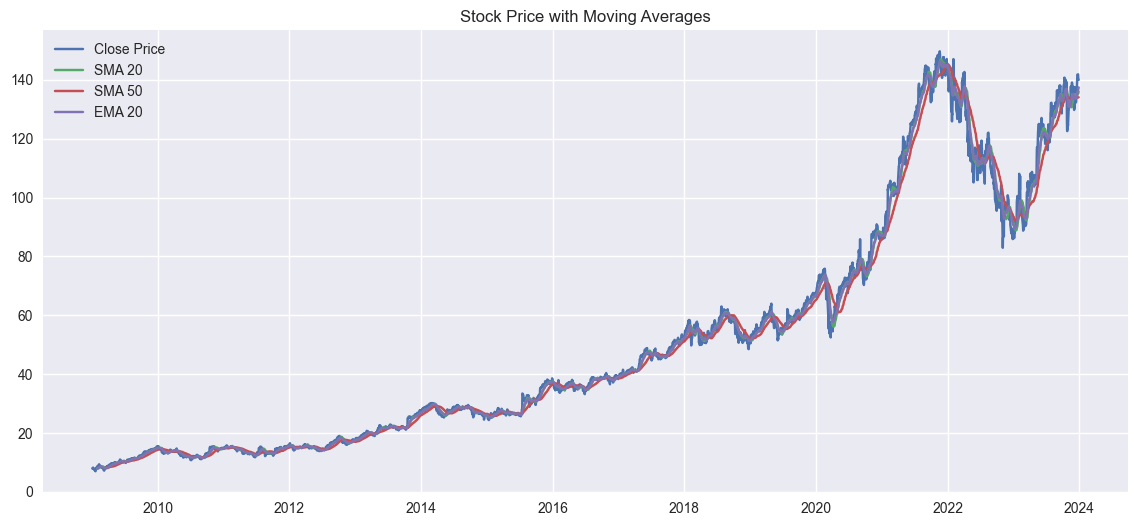

In [8]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['SMA_20'], label='SMA 20')
plt.plot(df['SMA_50'], label='SMA 50')
plt.plot(df['EMA_20'], label='EMA 20')
plt.title("Stock Price with Moving Averages")
plt.legend()
plt.show()


#### RSI Plot

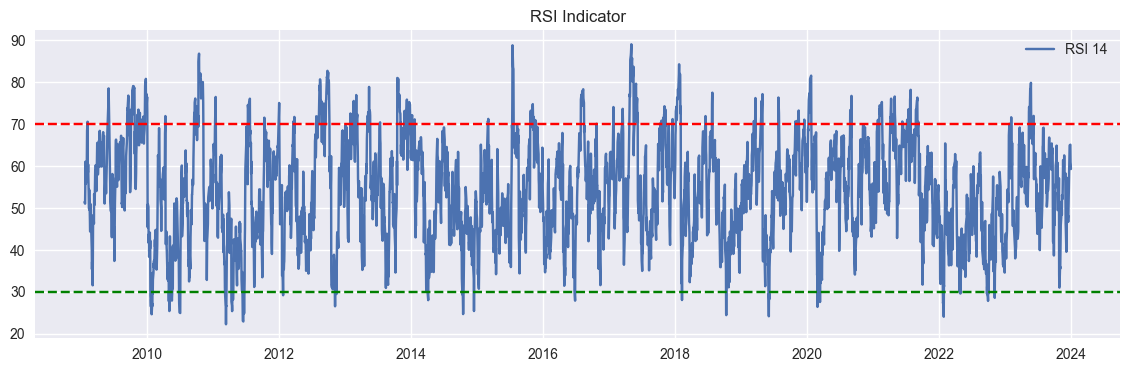

In [9]:
plt.figure(figsize=(14,4))
plt.plot(df['RSI_14'], label='RSI 14')
plt.axhline(70, color='red', linestyle='--')
plt.axhline(30, color='green', linestyle='--')
plt.title("RSI Indicator")
plt.legend()
plt.show()


#### MACD Plot

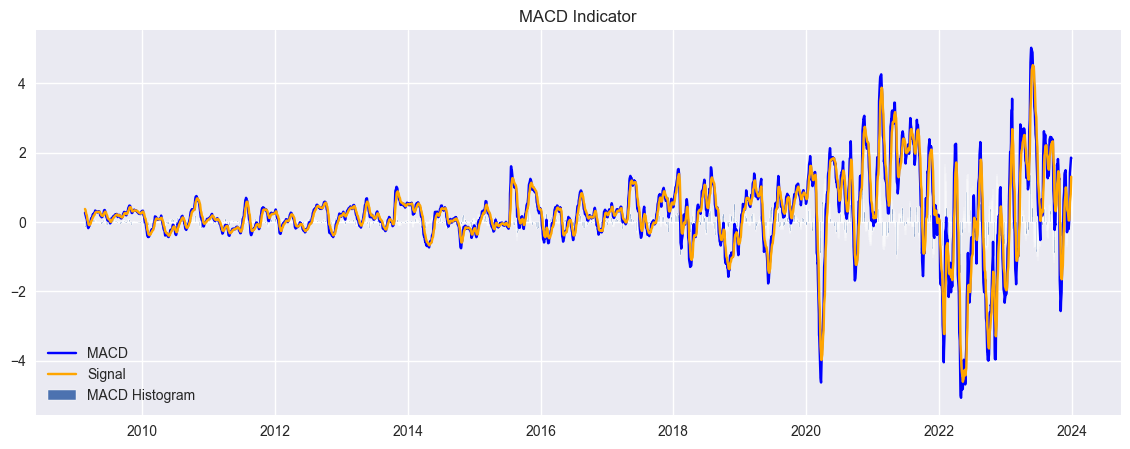

In [10]:
plt.figure(figsize=(14,5))
plt.plot(df['MACD'], label='MACD', color='blue')
plt.plot(df['MACD_signal'], label='Signal', color='orange')
plt.bar(df.index, df['MACD_hist'], label='MACD Histogram')
plt.title("MACD Indicator")
plt.legend()
plt.show()


#### Bollinger Bands

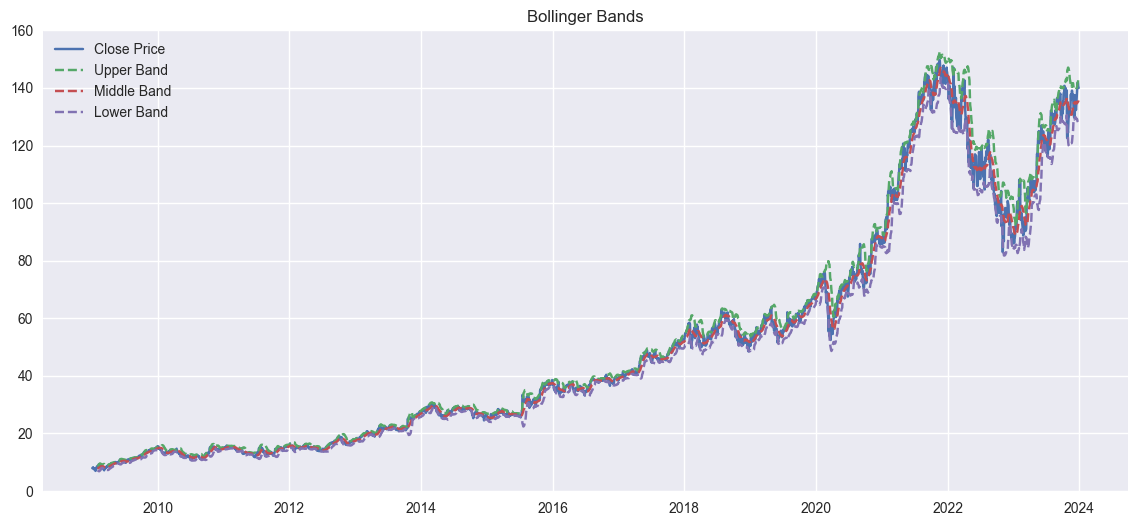

In [11]:
plt.figure(figsize=(14,6))
plt.plot(df['Close'], label='Close Price')
plt.plot(df['BB_upper'], label='Upper Band', linestyle='--')
plt.plot(df['BB_middle'], label='Middle Band', linestyle='--')
plt.plot(df['BB_lower'], label='Lower Band', linestyle='--')
plt.title("Bollinger Bands")
plt.legend()
plt.show()


### Quick look at price and volume

              count          mean           std            min           25%  \
Close        3774.0  5.077997e+01  3.941744e+01       6.994490  1.685109e+01   
High         3774.0  5.128516e+01  3.985330e+01       7.408840  1.698442e+01   
Low          3774.0  5.025235e+01  3.897505e+01       6.994490  1.669939e+01   
Open         3774.0  5.075353e+01  3.938974e+01       7.133018  1.682765e+01   
Volume       3774.0  6.123096e+07  5.537396e+07  158434.000000  2.574863e+07   
SMA_20       3755.0  5.066799e+01  3.916286e+01       7.885330  1.700126e+01   
SMA_50       3725.0  5.050240e+01  3.880745e+01       8.157327  1.729904e+01   
EMA_20       3755.0  5.066931e+01  3.914645e+01       7.885330  1.702051e+01   
RSI_14       3760.0  5.433298e+01  1.206629e+01      22.277545  4.544196e+01   
MACD         3741.0  2.380669e-01  1.104653e+00      -5.071179 -1.561624e-01   
MACD_signal  3741.0  2.371009e-01  1.028660e+00      -4.607953 -1.433565e-01   
MACD_hist    3741.0  9.660244e-04  3.588

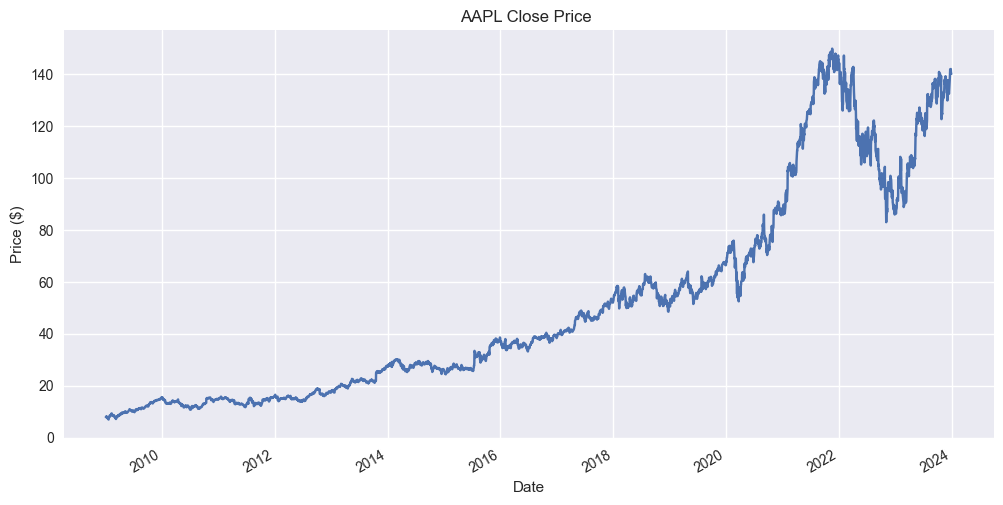

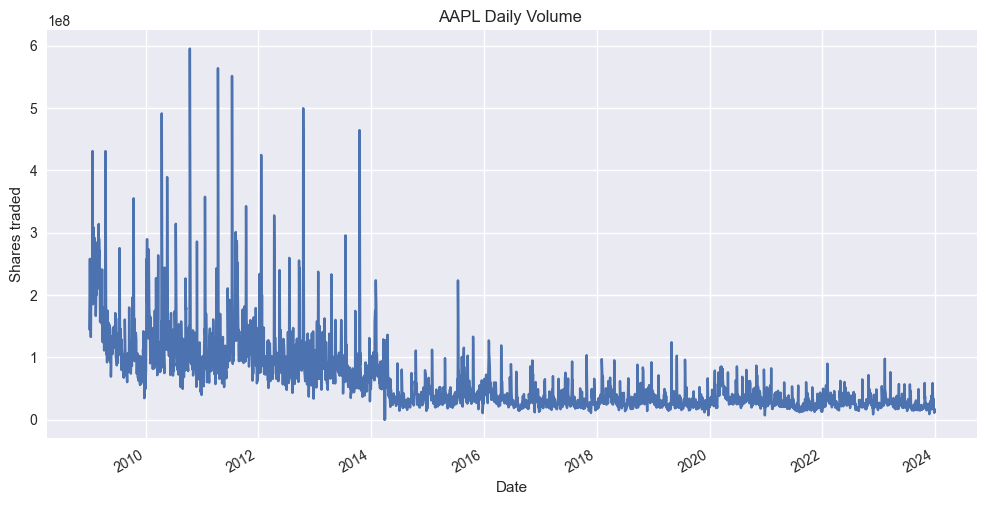

In [12]:
print(df.describe().T)

# Close price chart
df["Close"].plot(title="AAPL Close Price ")
plt.ylabel("Price ($)")
plt.show()

# Volume chart
df["Volume"].plot(title="AAPL Daily Volume ")
plt.ylabel("Shares traded")
plt.show()


### Compute technical indicators with TA-Lib

In [13]:
# Use 'Adj Close' if available, otherwise 'Close'
if "Adj Close" in df.columns:
    price = df["Adj Close"]
else:
    price = df["Close"]

# --- Moving Averages ---
df["SMA_20"] = talib.SMA(price, timeperiod=20)
df["SMA_50"] = talib.SMA(price, timeperiod=50)
df["EMA_20"] = talib.EMA(price, timeperiod=20)

# --- RSI ---
df["RSI_14"] = talib.RSI(price, timeperiod=14)

# --- MACD ---
df["MACD"], df["MACD_signal"], df["MACD_hist"] = talib.MACD(
    price, fastperiod=12, slowperiod=26, signalperiod=9
)


df.tail()


,Close,High,Low,Open,Volume,SMA_20,SMA_50,EMA_20,RSI_14,MACD,MACD_signal,MACD_hist,BB_upper,BB_middle,BB_lower
Date,,,,,,,,,,,,,,,
2023-12-22,141.750000,142.276397,141.089511,141.164014,18513500,135.009596,133.914786,135.854576,64.953309,1.412015,0.572046,0.839969,141.503046,135.009596,128.516146
2023-12-26,141.849304,142.966658,141.531472,142.008205,11170100,135.246477,133.999010,136.425503,65.115870,1.706565,0.798950,0.907615,142.346688,135.246477,128.146265
2023-12-27,140.478683,142.345911,140.092320,141.859236,17288400,135.386520,134.017881,136.811520,60.916026,1.808553,1.000870,0.807682,142.777559,135.386520,127.995480
2023-12-28,140.319748,141.303025,139.870824,140.885881,12192500,135.628861,134.023641,137.145637,60.429303,1.855168,1.171730,0.683438,143.326809,135.628861,127.930914
2023-12-29,139.972137,140.473710,138.949139,139.723837,14881000,135.976979,134.056417,137.414827,59.313063,1.842820,1.305948,0.536872,143.798395,135.976979,128.155563


### Price + SMA + Bollinger Bands

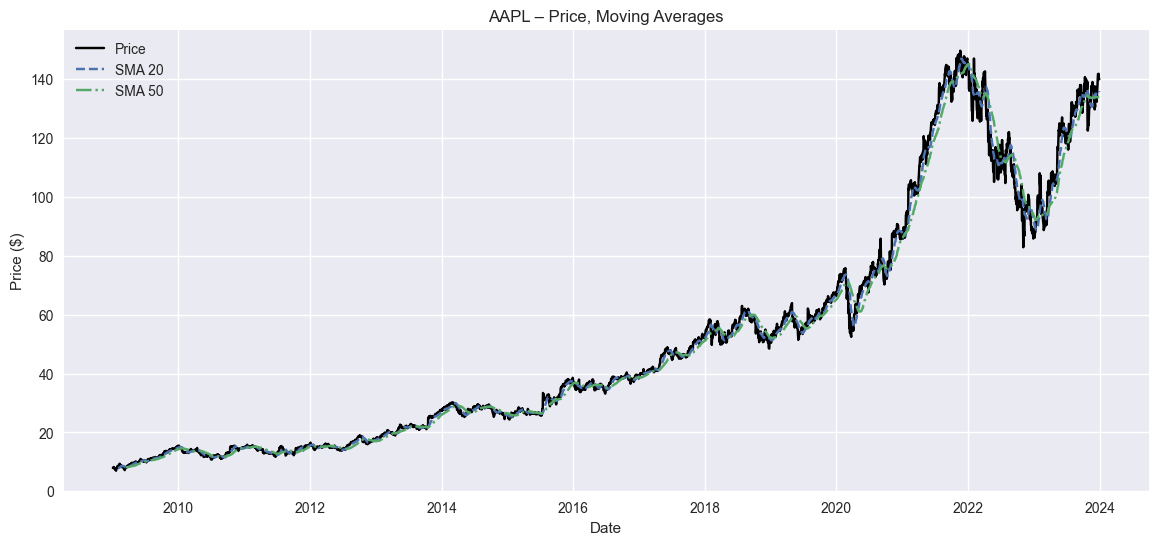

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, price, label="Price", color="black")
ax.plot(df.index, df["SMA_20"], label="SMA 20", linestyle="--")
ax.plot(df.index, df["SMA_50"], label="SMA 50", linestyle="-.")


ax.set_title("AAPL – Price, Moving Averages")
ax.set_xlabel("Date")
ax.set_ylabel("Price ($)")
ax.legend()
plt.show()


### RSI – Overbought / Oversold

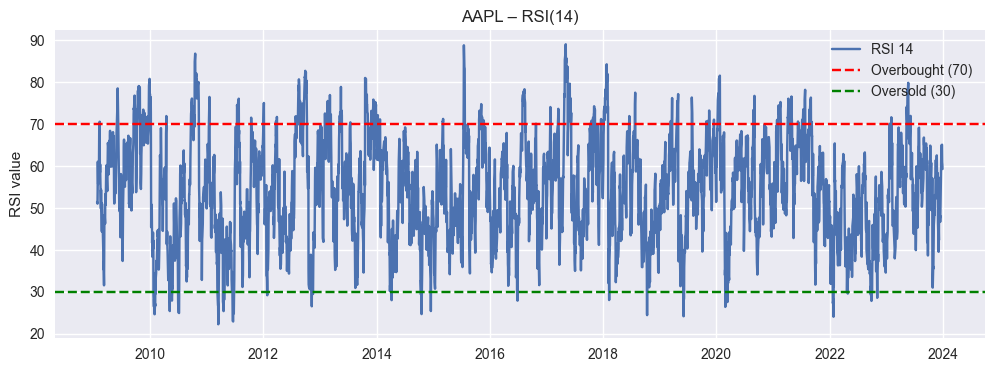

In [15]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["RSI_14"], label="RSI 14")
ax.axhline(70, color="red", linestyle="--", label="Overbought (70)")
ax.axhline(30, color="green", linestyle="--", label="Oversold (30)")

ax.set_title("AAPL – RSI(14)")
ax.set_ylabel("RSI value")
ax.legend()
plt.show()


### MACD – Trend & momentum

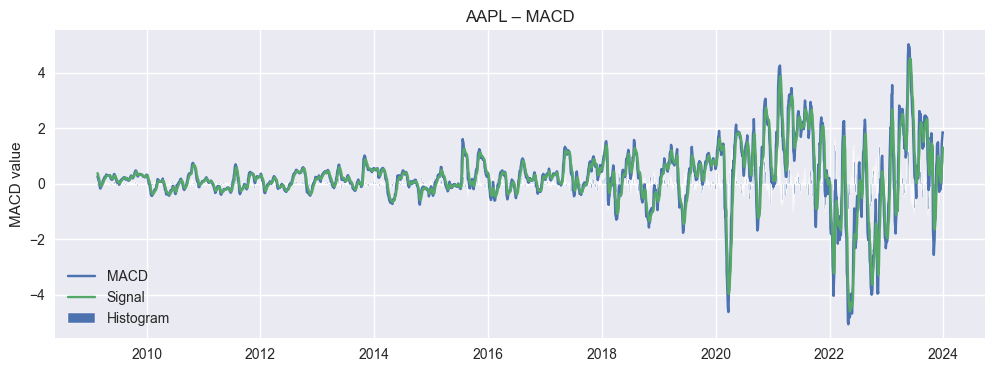

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(df.index, df["MACD"], label="MACD")
ax.plot(df.index, df["MACD_signal"], label="Signal")
ax.bar(df.index, df["MACD_hist"], label="Histogram")

ax.set_title("AAPL – MACD")
ax.set_ylabel("MACD value")
ax.legend()
plt.show()
